In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from pytorch_forecasting.data import TimeSeriesDataSet
from pytorch_forecasting.models import TemporalFusionTransformer
from torch.utils.data import DataLoader

# ---- Paths (as you gave) ----
PATH_H1 = r"C:\Users\admin\Desktop\Forex_algo\code\tft_ret_rich_v5.ckpt"
PATH_H4 = r"c:\Users\admin\Desktop\Forex_algo\code\lightning_logs\version_57\checkpoints\eurusd_h4_tft-epoch=20-val_loss=0.001522.ckpt"
DATA_H1 = r"C:\Users\admin\Desktop\Forex_algo\code\Data\EUR_USD_H1.parquet"
DATA_H4 = r"C:\Users\admin\Desktop\Forex_algo\code\Data\EUR_USD_H4.parquet"

# ---- Project root so we can import indicators.py ----
project_root = Path(r"C:\Users\admin\Desktop\Forex_algo\code")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

device = "cuda" if torch.cuda.is_available() else "cpu"
device


c:\Users\admin\Desktop\Forex_algo\code\venv\Lib\site-packages\pytorch_forecasting\models\base\_base_model.py:28: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


'cuda'

In [25]:
# Load H1 parquet
df_h1 = pd.read_parquet(DATA_H1)

print("Raw H1 shape:", df_h1.shape)
print("Columns:", df_h1.columns.tolist())

# Ensure datetime and set index
df_h1["time"] = pd.to_datetime(df_h1["time"])
df_h1 = df_h1.sort_values("time").set_index("time")

# Target: next-hour log return on mid_c
df_h1["target_return"] = np.log(df_h1["mid_c"].shift(-1)) - np.log(df_h1["mid_c"])

# Drop last row (no target)
df_h1 = df_h1.iloc[:-1].copy()

print("After target, H1 shape:", df_h1.shape)
print("NaNs in target_return:", df_h1["target_return"].isna().sum())
df_h1.head()


Raw H1 shape: (61473, 14)
Columns: ['time', 'volume', 'mid_o', 'mid_h', 'mid_l', 'mid_c', 'bid_o', 'bid_h', 'bid_l', 'bid_c', 'ask_o', 'ask_h', 'ask_l', 'ask_c']
After target, H1 shape: (61472, 14)
NaNs in target_return: 0


,volume,mid_o,mid_h,mid_l,mid_c,bid_o,bid_h,bid_l,bid_c,ask_o,ask_h,ask_l,ask_c,target_return
time,,,,,,,,,,,,,,
2016-01-07 00:00:00+00:00,542,1.07764,1.07832,1.07744,1.07778,1.07757,1.07823,1.07735,1.07770,1.07772,1.07840,1.07752,1.07787,0.002326
2016-01-07 01:00:00+00:00,3167,1.07776,1.08100,1.07748,1.08029,1.07768,1.08092,1.07740,1.08020,1.07784,1.08109,1.07756,1.08038,0.001138
2016-01-07 02:00:00+00:00,1567,1.08026,1.08176,1.07996,1.08152,1.08018,1.08169,1.07987,1.08144,1.08035,1.08184,1.08005,1.08159,0.000324
2016-01-07 03:00:00+00:00,914,1.08156,1.08257,1.08150,1.08187,1.08147,1.08249,1.08142,1.08178,1.08164,1.08265,1.08157,1.08196,0.000453
2016-01-07 04:00:00+00:00,649,1.08190,1.08256,1.08156,1.08236,1.08182,1.08247,1.08147,1.08228,1.08199,1.08264,1.08163,1.08245,0.000333


In [26]:
def compute_rsi(series: pd.Series, period: int = 14) -> pd.Series:
    delta = series.diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)

    avg_gain = gain.rolling(window=period, min_periods=period).mean()
    avg_loss = loss.rolling(window=period, min_periods=period).mean()

    rs  = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

def add_indicators_and_features(df: pd.DataFrame) -> pd.DataFrame:
    # ---- RSI 14 ----
    df["rsi"] = compute_rsi(df["mid_c"], period=14)

    # ---- MACD (12, 26, 9) ----
    ema_fast = df["mid_c"].ewm(span=12, min_periods=12).mean()
    ema_slow = df["mid_c"].ewm(span=26, min_periods=26).mean()
    df["macd"] = ema_fast - ema_slow
    df["macd_signal"] = df["macd"].ewm(span=9, min_periods=9).mean()

    # ---- Bollinger Bands (20, 2) ----
    typical = (df["mid_c"] + df["mid_h"] + df["mid_l"]) / 3
    rolling_mean = typical.rolling(window=20, min_periods=20).mean()
    rolling_std  = typical.rolling(window=20, min_periods=20).std()

    df["bb_middle"] = rolling_mean
    df["bb_upper"]  = rolling_mean + 2 * rolling_std
    df["bb_lower"]  = rolling_mean - 2 * rolling_std

    # ---- ATR 14 ----
    prev_close = df["mid_c"].shift(1)
    tr1 = df["mid_h"] - df["mid_l"]
    tr2 = (df["mid_h"] - prev_close).abs()
    tr3 = (prev_close - df["mid_l"]).abs()
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    df["atr14"] = tr.rolling(window=14, min_periods=14).mean()

    # ---- EMAs ----
    for span, col in [(5, "ema_5"), (20, "ema_20"), (50, "ema_50"), (200, "ema_200")]:
        df[col] = df["mid_c"].ewm(span=span, min_periods=span).mean()

    # ---- Engineered features ----
    df["momentum_oc"] = df["mid_o"] - df["mid_c"]
    df["avg_price_hl"] = (df["mid_h"] + df["mid_l"]) / 2
    df["range_hl"] = df["mid_h"] - df["mid_l"]
    df["typical_price_ohlc"] = (df["mid_o"] + df["mid_h"] + df["mid_l"] + df["mid_c"]) / 4
    df["log_volume"] = np.log(df["volume"] + 1)

    return df

df_h1 = add_indicators_and_features(df_h1)

print("After indicators, H1 shape:", df_h1.shape)
print("NaNs per column (first 20):")
print(df_h1.isna().sum().sort_values(ascending=False).head(20))
df_h1.head()


After indicators, H1 shape: (61472, 30)
NaNs per column (first 20):
ema_200               199
ema_50                 49
macd_signal            33
macd                   25
ema_20                 19
bb_lower               19
bb_upper               19
bb_middle              19
rsi                    14
atr14                  13
ema_5                   4
typical_price_ohlc      0
range_hl                0
avg_price_hl            0
momentum_oc             0
volume                  0
mid_o                   0
target_return           0
ask_c                   0
ask_l                   0
dtype: int64


,volume,mid_o,mid_h,mid_l,mid_c,bid_o,bid_h,bid_l,bid_c,ask_o,...,atr14,ema_5,ema_20,ema_50,ema_200,momentum_oc,avg_price_hl,range_hl,typical_price_ohlc,log_volume
time,,,,,,,,,,,,,,,,,,,,,
2016-01-07 00:00:00+00:00,542,1.07764,1.07832,1.07744,1.07778,1.07757,1.07823,1.07735,1.07770,1.07772,...,NaN,NaN,NaN,NaN,NaN,-0.00014,1.077880,0.00088,1.077795,6.297109
2016-01-07 01:00:00+00:00,3167,1.07776,1.08100,1.07748,1.08029,1.07768,1.08092,1.07740,1.08020,1.07784,...,NaN,NaN,NaN,NaN,NaN,-0.00253,1.079240,0.00352,1.079133,8.060856
2016-01-07 02:00:00+00:00,1567,1.08026,1.08176,1.07996,1.08152,1.08018,1.08169,1.07987,1.08144,1.08035,...,NaN,NaN,NaN,NaN,NaN,-0.00126,1.080860,0.00180,1.080875,7.357556
2016-01-07 03:00:00+00:00,914,1.08156,1.08257,1.08150,1.08187,1.08147,1.08249,1.08142,1.08178,1.08164,...,NaN,NaN,NaN,NaN,NaN,-0.00031,1.082035,0.00107,1.081875,6.818924
2016-01-07 04:00:00+00:00,649,1.08190,1.08256,1.08156,1.08236,1.08182,1.08247,1.08147,1.08228,1.08199,...,NaN,1.081509,NaN,NaN,NaN,-0.00046,1.082060,0.00100,1.082095,6.476972


In [27]:
# Features we want the model to see
FEATURE_COLS = [
    "mid_c",
    "volume",
    "rsi",
    "macd",
    "macd_signal",
    "bb_lower",
    "bb_middle",
    "bb_upper",
    "atr14",
    "ema_5",
    "ema_20",
    "ema_50",
    "ema_200",
    "momentum_oc",
    "avg_price_hl",
    "range_hl",
    "typical_price_ohlc",
    "log_volume",
]

print("FEATURE_COLS:", FEATURE_COLS)
missing = [c for c in FEATURE_COLS if c not in df_h1.columns]
print("Missing in df_h1:", missing)

# Keep only features that actually exist (just in case)
FEATURE_COLS = [c for c in FEATURE_COLS if c in df_h1.columns]
print("Effective FEATURE_COLS used:", FEATURE_COLS)

# 1) Replace inf/-inf with NaN in features + target
cols_to_clean = FEATURE_COLS + ["target_return"]

for col in cols_to_clean:
    df_h1[col] = df_h1[col].replace([np.inf, -np.inf], np.nan)

# 2) Drop rows where target is NaN (end of series / undefined)
df_h1 = df_h1.dropna(subset=["target_return"]).copy()

# 3) Forward-fill then back-fill features to remove remaining NaNs (e.g., indicator warmup)
df_h1[cols_to_clean] = df_h1[cols_to_clean].ffill().bfill()

print("\nNaNs per cleaned column:")
print(df_h1[cols_to_clean].isna().sum())
print("\nAny NaNs left in rsi?:", df_h1["rsi"].isna().any())
print("Final H1 shape after cleaning:", df_h1.shape)


FEATURE_COLS: ['mid_c', 'volume', 'rsi', 'macd', 'macd_signal', 'bb_lower', 'bb_middle', 'bb_upper', 'atr14', 'ema_5', 'ema_20', 'ema_50', 'ema_200', 'momentum_oc', 'avg_price_hl', 'range_hl', 'typical_price_ohlc', 'log_volume']
Missing in df_h1: []
Effective FEATURE_COLS used: ['mid_c', 'volume', 'rsi', 'macd', 'macd_signal', 'bb_lower', 'bb_middle', 'bb_upper', 'atr14', 'ema_5', 'ema_20', 'ema_50', 'ema_200', 'momentum_oc', 'avg_price_hl', 'range_hl', 'typical_price_ohlc', 'log_volume']

NaNs per cleaned column:
mid_c                 0
volume                0
rsi                   0
macd                  0
macd_signal           0
bb_lower              0
bb_middle             0
bb_upper              0
atr14                 0
ema_5                 0
ema_20                0
ema_50                0
ema_200               0
momentum_oc           0
avg_price_hl          0
range_hl              0
typical_price_ohlc    0
log_volume            0
target_return         0
dtype: int64

Any NaNs l

In [28]:
# Make sure sorted by time index
df_h1 = df_h1.sort_index()

# Add time_idx and series_id
df_h1["time_idx"] = np.arange(len(df_h1))
df_h1["series_id"] = "eurusd"
df_h1["series_id"] = df_h1["series_id"].astype("category")

# Time categoricals as strings (for TimeSeriesDataSet)
df_h1["hour"] = df_h1.index.hour.astype(str)
df_h1["day_of_week"] = df_h1.index.dayofweek.astype(str)

print(df_h1.dtypes[["series_id", "hour", "day_of_week"]])

# Split: 70% train, 15% val, 15% test
n = len(df_h1)
train_end = int(n * 0.7)
val_end   = int(n * 0.85)

train_df = df_h1.iloc[:train_end].copy()
val_df   = df_h1.iloc[train_end:val_end].copy()
test_df  = df_h1.iloc[val_end:].copy()

print("Split sizes -> train / val / test:", len(train_df), len(val_df), len(test_df))
print("Train rsi NaNs:", train_df["rsi"].isna().sum())


series_id      category
hour             object
day_of_week      object
dtype: object
Split sizes -> train / val / test: 43030 9221 9221
Train rsi NaNs: 0


In [29]:
MAX_ENCODER_LENGTH = 96
MAX_PREDICTION_LENGTH = 1
BATCH_SIZE = 256

training_h1 = TimeSeriesDataSet(
    train_df,
    time_idx="time_idx",
    target="target_return",
    group_ids=["series_id"],
    max_encoder_length=MAX_ENCODER_LENGTH,
    max_prediction_length=MAX_PREDICTION_LENGTH,
    time_varying_unknown_reals=FEATURE_COLS,
    time_varying_known_categoricals=["hour", "day_of_week"],
    static_categoricals=["series_id"],
    target_normalizer=None,          # stay compatible with your live engine
    allow_missing_timesteps=True,
    add_relative_time_idx=True,
    add_encoder_length=True,
    add_target_scales=False,
)

validation_h1 = TimeSeriesDataSet.from_dataset(
    training_h1,
    data=val_df,
    stop_randomization=True,
)
test_h1 = TimeSeriesDataSet.from_dataset(
    training_h1,
    data=test_df,
    stop_randomization=True,
)

train_loader_h1 = DataLoader(training_h1, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4)
val_loader_h1   = DataLoader(validation_h1, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader_h1  = DataLoader(test_h1, batch_size=BATCH_SIZE, shuffle=False,   num_workers=4)

len(training_h1), len(validation_h1), len(test_h1)


(42934, 9125, 9125)

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# --- Known performance from your previous runs ---

# H1 model: tft_ret_rich_v5.ckpt
mae_h1 = 0.00070327
dir_acc_h1 = 0.5010   # 50.10%

# H4 model: tft_h4-50.44.ckpt
mae_h4 = 0.00164022
dir_acc_h4 = 0.5044   # 50.44%

print("H1 model (tft_ret_rich_v5.ckpt)")
print(f"  MAE: {mae_h1:.8f}")
print(f"  Direction accuracy: {dir_acc_h1*100:.2f}%")

print("\nH4 model (tft_h4-50.44.ckpt)")
print(f"  MAE: {mae_h4:.8f}")
print(f"  Direction accuracy: {dir_acc_h4*100:.2f}%")


H1 model (tft_ret_rich_v5.ckpt)
  MAE: 0.00070327
  Direction accuracy: 50.10%

H4 model (tft_h4-50.44.ckpt)
  MAE: 0.00164022
  Direction accuracy: 50.44%


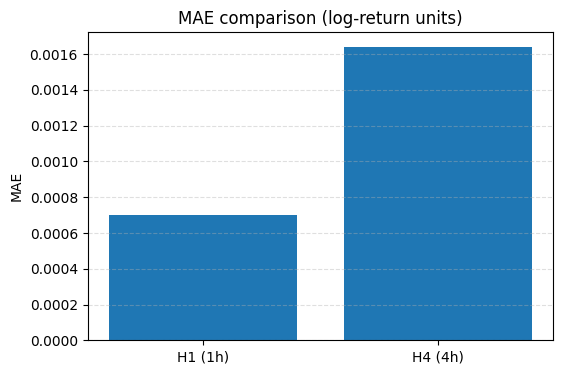

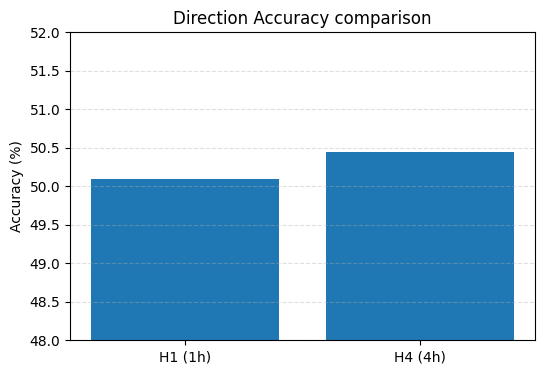

In [31]:
# Compare MAE
models = ["H1 (1h)", "H4 (4h)"]
maes = [mae_h1, mae_h4]

plt.figure(figsize=(6,4))
plt.bar(models, maes)
plt.title("MAE comparison (log-return units)")
plt.ylabel("MAE")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

# Compare direction accuracy
dir_accs = [dir_acc_h1 * 100, dir_acc_h4 * 100]

plt.figure(figsize=(6,4))
plt.bar(models, dir_accs)
plt.title("Direction Accuracy comparison")
plt.ylabel("Accuracy (%)")
plt.ylim(48, 52)   # zoom around 50%
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()


In [32]:
# Weights based on inverse MAE (better MAE => bigger weight)
w_h1 = 1.0 / mae_h1
w_h4 = 1.0 / mae_h4

print("H1 weight:", w_h1)
print("H4 weight:", w_h4)

def combine_h1_h4_signal(
    ret_h1: float,
    ret_h4: float,
    w_h1: float = w_h1,
    w_h4: float = w_h4,
    base_threshold: float = 0.0003,
):
    """
    Combine H1 and H4 TFT predictions into a single trading decision.
    
    ret_h1, ret_h4: predicted log-returns for next 1h and next 4h.
    w_h1, w_h4: weights (default = inverse MAE).
    base_threshold: minimum absolute score to take a trade.
    """
    # Raw directions
    dir_h1 = np.sign(ret_h1)
    dir_h4 = np.sign(ret_h4)

    # Weighted combined score
    score = w_h1 * ret_h1 + w_h4 * ret_h4

    # Normalize score by (w_h1 + w_h4) to keep it in a reasonable range
    score_norm = score / (w_h1 + w_h4)

    # Dynamic threshold: base_threshold scaled by volatility of H1 prediction
    # (you can tune this, or even use ATR)
    threshold = base_threshold

    # ---- Decision rules ----
    # If they disagree in direction -> HOLD
    if dir_h1 * dir_h4 < 0:
        return "HOLD", score_norm

    # If both predict upward and score is strong -> BUY
    if score_norm > threshold and dir_h1 > 0 and dir_h4 > 0:
        return "BUY", score_norm

    # If both predict downward and score is strong -> SELL
    if score_norm < -threshold and dir_h1 < 0 and dir_h4 < 0:
        return "SELL", score_norm

    # Otherwise -> HOLD (signal too weak)
    return "HOLD", score_norm


H1 weight: 1421.928988866296
H4 weight: 609.6743119825389


In [33]:
# Example simulated predictions for next bar:
examples = [
    ("Strong up on both",  +0.0010, +0.0015),
    ("Weak up H1, strong up H4", +0.0002, +0.0012),
    ("Up H1, down H4 (conflict)", +0.0008, -0.0007),
    ("Strong down on both", -0.0012, -0.0016),
    ("Very small moves", +0.00005, -0.00002),
]

for desc, h1_ret, h4_ret in examples:
    decision, score = combine_h1_h4_signal(h1_ret, h4_ret)
    print(f"{desc:30s} | H1={h1_ret:+0.6f} H4={h4_ret:+0.6f} -> {decision} (score={score:+0.6f})")


Strong up on both              | H1=+0.001000 H4=+0.001500 -> BUY (score=+0.001150)
Weak up H1, strong up H4       | H1=+0.000200 H4=+0.001200 -> BUY (score=+0.000500)
Up H1, down H4 (conflict)      | H1=+0.000800 H4=-0.000700 -> HOLD (score=+0.000350)
Strong down on both            | H1=-0.001200 H4=-0.001600 -> SELL (score=-0.001320)
Very small moves               | H1=+0.000050 H4=-0.000020 -> HOLD (score=+0.000029)


In [34]:
# Example: using real predictions (replace with your actual values)
pred_ret_h1 = 0.00045   # from H1 TFT
pred_ret_h4 = 0.00090   # from H4 TFT

final_signal, combined_score = combine_h1_h4_signal(pred_ret_h1, pred_ret_h4)

print("H1 predicted return:", pred_ret_h1)
print("H4 predicted return:", pred_ret_h4)
print("Final combined signal:", final_signal)
print("Combined normalized score:", combined_score)


H1 predicted return: 0.00045
H4 predicted return: 0.0009
Final combined signal: BUY
Combined normalized score: 0.0005850428207502485


In [35]:
# Load both timeframes
df_h1 = pd.read_parquet(DATA_H1)
df_h4 = pd.read_parquet(DATA_H4)

df_h1["time"] = pd.to_datetime(df_h1["time"])
df_h4["time"] = pd.to_datetime(df_h4["time"])

df_h1.set_index("time", inplace=True)
df_h4.set_index("time", inplace=True)

# Compute next-return for prediction
df_h1["target_return"] = df_h1["mid_c"].pct_change().shift(-1)
df_h4["target_return"] = df_h4["mid_c"].pct_change().shift(-1)

# Remove NaNs
df_h1.dropna(inplace=True)
df_h4.dropna(inplace=True)


In [36]:
# Add basics for both datasets
for df in (df_h1, df_h4):
    df["time_idx"] = np.arange(len(df))
    df["series_id"] = 0
    df["hour"] = df.index.hour.astype(str)
    df["day_of_week"] = df.index.dayofweek.astype(str)

# Minimal features
BASE_FEATURES = ["mid_c"]

# H1 dataset
ts_h1 = TimeSeriesDataSet(
    df_h1,
    time_idx="time_idx",
    target="target_return",
    group_ids=["series_id"],
    max_encoder_length=96,
    max_prediction_length=1,
    time_varying_unknown_reals=BASE_FEATURES,
    time_varying_known_categoricals=["hour", "day_of_week"],
)

loader_h1 = DataLoader(ts_h1, batch_size=256, shuffle=False)

# H4 dataset
ts_h4 = TimeSeriesDataSet(
    df_h4,
    time_idx="time_idx",
    target="target_return",
    group_ids=["series_id"],
    max_encoder_length=24,
    max_prediction_length=1,
    time_varying_unknown_reals=BASE_FEATURES,
    time_varying_known_categoricals=["hour", "day_of_week"],
)

loader_h4 = DataLoader(ts_h4, batch_size=256, shuffle=False)


In [37]:
tft_h1 = TemporalFusionTransformer.load_from_checkpoint(PATH_H1).to(device)
tft_h4 = TemporalFusionTransformer.load_from_checkpoint(PATH_H4).to(device)

tft_h1.eval()
tft_h4.eval()

print("Loaded both models.")


c:\Users\admin\Desktop\Forex_algo\code\venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:210: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\admin\Desktop\Forex_algo\code\venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:210: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


Loaded both models.


In [ ]:
# H1 predictions
preds_h1 = tft_h1.predict(loader_h1, return_x=False).detach().cpu().numpy().flatten()
true_h1 = df_h1["target_return"].values[:len(preds_h1)]

# H4 predictions
preds_h4 = tft_h4.predict(loader_h4, return_x=False).detach().cpu().numpy().flatten()
true_h4 = df_h4["target_return"].values[:len(preds_h4)]


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA GeForce RTX 4070 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\admin\Desktop\Forex_algo\code\venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:433: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoad

TypeError: default_collate: batch must contain tensors, numpy arrays, numbers, dicts or lists; found <class 'NoneType'>

: 